In [4]:
#image import for processing

from PIL import Image
import numpy as np
from IPython.display import display

def import_for_pillow(path):
    img = Image.open(path)

    print(f"   Format: {img.format}")
    print(f"   Size: {img.size}")  
    print(f"   Mode: {img.mode}")  

    if img.mode != 'RGB':
        img = img.convert('RGB')

    img_array = np.array(img)

    return img, img_array
pil_img, array = import_for_pillow("C:/Users/Amine/Documents/2026_projects/bees project/HU-wing-images/HU-0001-2019-000003-R.dw.png")

   Format: PNG
   Size: (871, 329)
   Mode: L


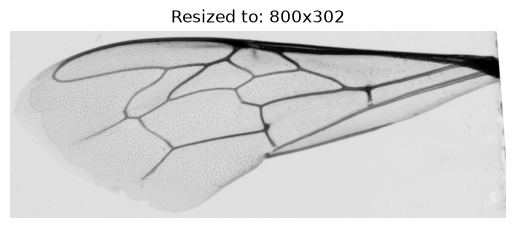

In [5]:
# Grayscaling and downsizing the image 

import cv2
import matplotlib.pyplot as plt

def smart_resize_grayscale(img, max_dimension=800):
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    height, width = gray.shape
    scale = min(max_dimension / height, max_dimension / width)
    
    new_width = int(width * scale)
    new_height = int(height * scale)

    resized = cv2.resize(gray, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4)

    return resized

image_gray = smart_resize_grayscale(array, max_dimension=800)

plt.imshow(image_gray, cmap='gray')
plt.axis('off')
plt.title(f"Resized to: {image_gray.shape[1]}x{image_gray.shape[0]}")
plt.show()

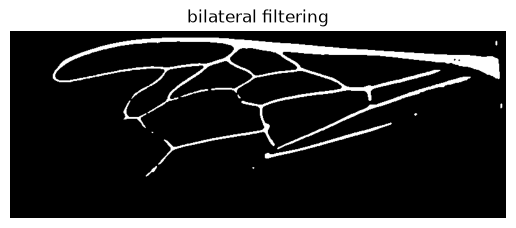

In [6]:
# generating binary image preparing for skeletonization

# bilateral = cv2.bilateralFilter(image_gray, d=30, sigmaColor=65, sigmaSpace=2.5)

median1 = cv2.medianBlur(image_gray,5)

blur1 = cv2.GaussianBlur(median1, (0, 0), sigmaX=10)
blur2 = cv2.GaussianBlur(median1, (0, 0), sigmaX=0.1)

dog = cv2.subtract(blur1, blur2)

dog_abs = cv2.convertScaleAbs(dog)

_, thresh = cv2.threshold(dog_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

median2 = cv2.medianBlur(thresh,3)

plt.imshow(median2, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

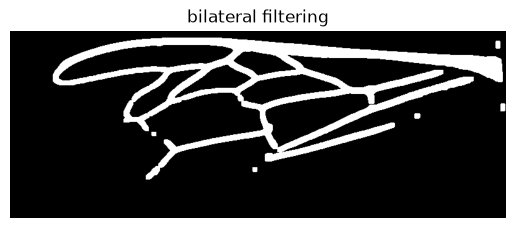

In [8]:
#dilation to deifne edges well

kernel = np.ones((2,2), np.uint8)

dilated_img = cv2.dilate(median2, kernel, iterations=5)

plt.imshow(dilated_img, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

C:\Users\Amine\AppData\Local\Temp\ipykernel_12072\1674318269.py:7: FutureWarning: `rectangle` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  selem = morphology.rectangle(1, dilated_img.shape[1] // 15)


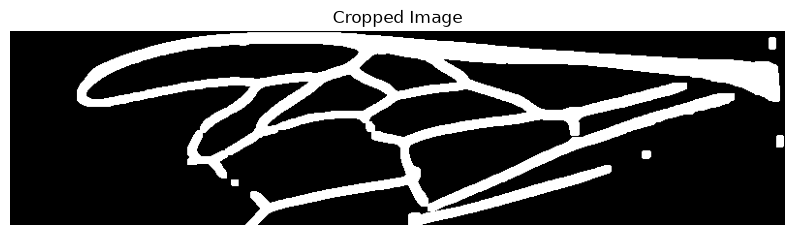

In [9]:
# auto cropping the image to focus on needed areas
from skimage import morphology
import numpy as np
import matplotlib.pyplot as plt

# Filter elements smaller than 1/6-th of the total width
selem = morphology.rectangle(1, dilated_img.shape[1] // 15)
img_opened = morphology.opening(dilated_img, selem)

hist = np.sum(img_opened, axis=1)
non_zero = np.where(hist > 0)[0]
top_bound = int(np.round(np.min(non_zero) * 0.95))
bottom_bound = int(np.round(np.max(non_zero) * 1.05))

# Crop the image
img_cropped = dilated_img[top_bound:bottom_bound, :]

# Display the cropped image
plt.figure(figsize=(10, 5))
plt.imshow(img_cropped, cmap='gray')
plt.title('Cropped Image')
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(799.5), np.float64(199.5), np.float64(-0.5))

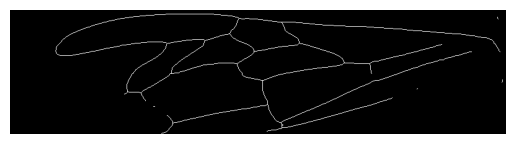

In [10]:
#skeletonizing the image 

from skimage.morphology import skeletonize

skeleton = skeletonize(img_cropped).astype(np.uint8) * 255

plt.imshow(skeleton, cmap='gray')
plt.axis('off')

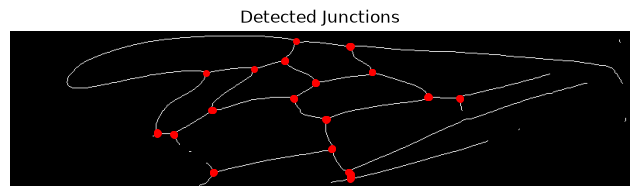

In [36]:
#detection of junction points

from skimage.feature import corner_harris, corner_peaks
from scipy.ndimage import convolve

binary = (img_cropped > 0).astype(np.uint8)
skeleton = skeletonize(binary).astype(np.uint8)

kernel = np.array([[1, 1, 1],
                   [1, 0, 1],
                   [1, 1, 1]])

neighbors = convolve(skeleton, kernel, mode='constant')
junction_mask = (skeleton == 1) & (neighbors >= 3)

margin = 20
h, w = skeleton.shape
junction_mask[:, :margin] = False
junction_mask[:, w-margin:] = False

ys, xs = np.where(junction_mask)

plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='gray')
plt.plot(xs, ys, 'ro', markersize=4)
plt.title('Detected Junctions')
plt.axis('off')
plt.show()

# Classification

we're going to use the skeleton image and the junction points 

so what are we thinking ? we know we're using KNN but we sure need to test other algorithms 

definetly need to test other improved neighbouring algortihms 

In [38]:
def extract_skeleton_and_junctions(image, max_dimension=800, margin=20):
 
    # ---- 1. Load image if a path was given ----
    if isinstance(image, str):
        loaded = cv2.imread(image, cv2.IMREAD_COLOR)
        if loaded is None:
            raise ValueError(f"Could not read image from path: {image}")
        img_array = loaded
    else:
        img_array = image
        if img_array.ndim == 3 and img_array.shape[2] == 4:
            img_array = cv2.cvtColor(img_array, cv2.COLOR_RGBA2BGR)
 
    # ---- 2. Grayscale + resize ----
    if img_array.ndim == 3:
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_array
 
    height, width = gray.shape
    scale = min(max_dimension / height, max_dimension / width)
    new_width = int(width * scale)
    new_height = int(height * scale)
    image_gray = cv2.resize(
        gray, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4
    )
 
    # ---- 3. Binarization via difference-of-Gaussians + Otsu threshold ----
    median1 = cv2.medianBlur(image_gray, 5)
    blur1 = cv2.GaussianBlur(median1, (0, 0), sigmaX=10)
    blur2 = cv2.GaussianBlur(median1, (0, 0), sigmaX=0.1)
    dog = cv2.subtract(blur1, blur2)
    dog_abs = cv2.convertScaleAbs(dog)
    _, thresh = cv2.threshold(
        dog_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    median2 = cv2.medianBlur(thresh, 3)
 
    # ---- 4. Dilation to clean up / thicken edges ----
    kernel = np.ones((2, 2), np.uint8)
    dilated_img = cv2.dilate(median2, kernel, iterations=5)
 
    # ---- 5. Auto-crop to the wing region ----
    selem = morphology.footprint_rectangle((1, dilated_img.shape[1] // 15))
    img_opened = morphology.opening(dilated_img, selem)
 
    hist = np.sum(img_opened, axis=1)
    non_zero = np.where(hist > 0)[0]
    if len(non_zero) > 0:
        top_bound = int(np.round(np.min(non_zero) * 0.95))
        bottom_bound = int(np.round(np.max(non_zero) * 1.05))
        top_bound = max(top_bound, 0)
        bottom_bound = min(bottom_bound, dilated_img.shape[0])
        img_cropped = dilated_img[top_bound:bottom_bound, :]
    else:
        img_cropped = dilated_img
 
    # ---- 6. Skeletonization ----
    binary = (img_cropped > 0).astype(np.uint8)
    skeleton_bin = skeletonize(binary).astype(np.uint8)
    skeleton = skeleton_bin * 255
 
    # ---- 7. Junction point detection ----
    neighbor_kernel = np.array(
        [[1, 1, 1],
         [1, 0, 1],
         [1, 1, 1]]
    )
    neighbors = convolve(skeleton_bin, neighbor_kernel, mode="constant")
    junction_mask = (skeleton_bin == 1) & (neighbors >= 3)
 
    h, w = skeleton_bin.shape
    if margin > 0 and w > 2 * margin:
        junction_mask[:, :margin] = False
        junction_mask[:, w - margin:] = False
 
    ys, xs = np.where(junction_mask)
    junctions = np.column_stack((xs, ys))
 
    return skeleton, junctions

In [41]:
import os
import pandas as pd

def process_images_to_csv(folder_path, label, output_csv="features.csv", max_dimension=800, margin=20):

    valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")
    rows = []

    if not os.path.isdir(folder_path):
        raise ValueError(f"Not a valid directory: {folder_path}")

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith(valid_exts):
            continue

        file_path = os.path.join(folder_path, filename)
        try:
            skeleton, junctions = extract_skeleton_and_junctions(
                file_path, max_dimension=max_dimension, margin=margin
            )
        except Exception as e:
            print(f"[WARN] Skipping {filename}: {e}")
            continue

        # Serialize skeleton (2D uint8 image) and junctions (Nx2 array) as strings
        skeleton_str = ";".join(
            ",".join(str(int(v)) for v in row) for row in skeleton
        )
        junctions_str = ";".join(
            f"{int(x)},{int(y)}" for x, y in junctions
        )

        rows.append({
            "id": filename,
            "skeleton": skeleton_str,
            "junctions": junctions_str,
            "label": label,
        })

    df_new = pd.DataFrame(rows, columns=["id", "skeleton", "junctions", "label"])

    # Append if file exists, otherwise write new
    if os.path.exists(output_csv):
        df_new.to_csv(output_csv, mode="a", header=False, index=False)
    else:
        df_new.to_csv(output_csv, mode="w", header=True, index=False)

    return df_new


process_images_to_csv("C:/Users/Amine/Documents/2026_projects/bees project/bees/samples_north", label="A.F intermissa", output_csv="AF_Intermissa.csv")

,id,skeleton,junctions,label
0,MA-0125-TT01-000879-R.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","385,19;446,27;447,27;448,27;447,28;374,40;373,...",A.F intermissa
1,MA-0125-TT01-000880-R.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","385,19;385,20;386,20;451,29;452,29;453,29;452,...",A.F intermissa
2,MA-0125-TT01-000881-R.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","386,24;456,34;457,34;458,34;457,35;458,40;458,...",A.F intermissa
3,MA-0125-TT01-000882-R.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","379,18;447,27;448,27;449,27;448,28;369,40;368,...",A.F intermissa
4,MA-0125-TT01-000883-R.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","317,11;317,12;318,12;336,12;337,12;338,12;317,...",A.F intermissa
...,...,...,...,...
178,MA-0142-SN13-000738-L.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","169,11;169,12;170,12;411,22;480,31;481,31;482,...",A.F intermissa
179,MA-0142-SN13-000739-L.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","393,22;393,23;394,23;457,31;458,31;459,31;458,...",A.F intermissa
180,MA-0142-SN13-000740-L.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","401,22;401,23;402,23;468,31;469,31;470,31;469,...",A.F intermissa
181,MA-0142-SN13-000741-L.dw.png,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","406,23;407,23;406,24;472,33;473,33;474,33;473,...",A.F intermissa
